In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [3]:
print(df)

      CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gender  ..

In [4]:
pd.isnull(df).sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Total Charges are in object type So we need to convert it to Numeric type

In [6]:
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

The country , State , Count Colummns only have one value so we won't require it

In [7]:
churn_count = df['Churn Value'].value_counts()
print("Churn Distribution:",churn_count)

Churn Distribution: Churn Value
0    5174
1    1869
Name: count, dtype: int64


Here the dataset is unbalanced. Majority of dataset is having 0 value i.e not churn
    This will affect the model in predicting a correct result

In [8]:
churn_percentage = (churn_count[1]/df.shape[0])*100
print("Churn percentage:",round(churn_percentage,2),"%")

Churn percentage: 26.54 %


In [9]:
tenure_churn = df.groupby('Churn Value')['Tenure Months'].mean()
print("\nAverage Tenure by Churn:")
print(tenure_churn)


Average Tenure by Churn:
Churn Value
0    37.569965
1    17.979133
Name: Tenure Months, dtype: float64


In [10]:
monthly_charges_churn = df.groupby('Churn Value')['Monthly Charges'].mean()
print("\nAverage Monthly Charges by Churn:")
print(monthly_charges_churn)


Average Monthly Charges by Churn:
Churn Value
0    61.265124
1    74.441332
Name: Monthly Charges, dtype: float64


In [11]:
selected = df.drop(columns = ['CustomerID']).select_dtypes(include = "object").columns
for col in selected:
    print("Value counts for column ",col)
    print(df[col].value_counts())

Value counts for column  Country
Country
United States    7043
Name: count, dtype: int64
Value counts for column  State
State
California    7043
Name: count, dtype: int64
Value counts for column  City
City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
                ... 
Chester            4
Big Bar            4
Washington         4
Stonyford          4
Stirling City      4
Name: count, Length: 1129, dtype: int64
Value counts for column  Lat Long
Lat Long
34.159534, -116.425984    5
33.28156, -115.955541     5
34.201108, -116.593456    5
33.798266, -118.300237    5
33.391181, -118.421305    5
                         ..
41.505916, -120.152505    4
41.764869, -122.671316    4
41.465121, -122.380947    4
40.021787, -122.127576    4
41.737962, -123.07557     4
Name: count, Length: 1652, dtype: int64
Value counts for column  Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64
Value counts for column  Senior Citiz

Value counts for column  Contract

Contract

Month-to-month    3875

Two year          1695

One year          1473

Value counts for column  Payment Method

Payment Method

Electronic check             2365

Mailed check                 1612

Bank transfer (automatic)    1544

Credit card (automatic)      1522


In [12]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [13]:
df[df['Total Charges'].isna()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


From the data set we see that 11 NULL values in total charges and the tenure months also 0 so we can multiply tenure months with monthly charges so the total charges become 0. And these customers does not churn as well.

In [14]:
df['Total Charges'].isna().sum()
df['Total Charges'] = df['Total Charges'].fillna(df['Monthly Charges']*df['Tenure Months'])
df['Total Charges'].isna().sum()

np.int64(0)

Another thing we can do is try to bring out some useful insight.

We can find out the difference betwee the total charge and our calculated charges.

Find out how many customer pay more than the charges defined for them.

Find out how many customer pay less than there defined charges.

In [15]:
df1 = df.copy(deep = True)
df1['Total_Charge'] = df['Total Charges']
df1['Monthly*Tenure'] = df1['Monthly Charges']*df1['Tenure Months']
df1['extra_charge']=(df1['Total_Charge']-df1['Monthly*Tenure']).clip(lower=0)
df1['less_charge']=(df1['Monthly*Tenure']-df1['Total_Charge']).clip(lower=0)
df1['diff']=(df1['Total_Charge']-df1['Monthly*Tenure'])

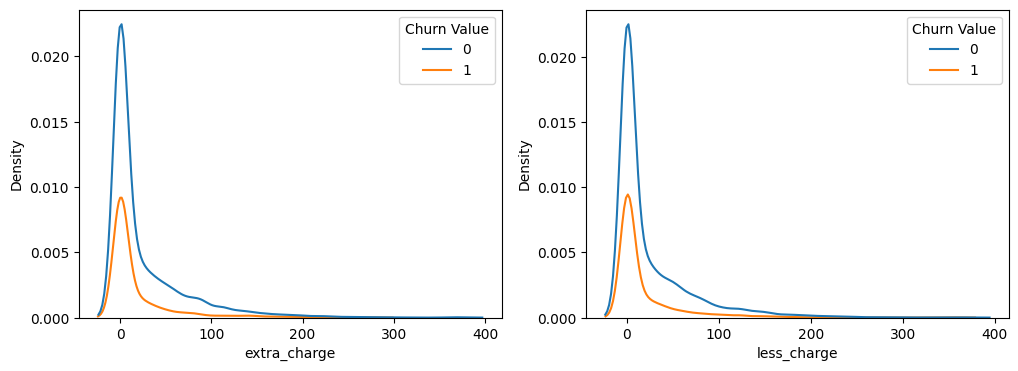

In [16]:
import seaborn as sns
plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
sns.kdeplot(data = df1 , x = 'extra_charge' , hue = 'Churn Value')
plt.subplot(1,2,2)
sns.kdeplot(data = df1 , x = 'less_charge' , hue = 'Churn Value')
plt.show()

In [17]:
(df1['diff'] == 0).mean()*100

np.float64(8.874059349708931)

8.9% of customers have exact billing

Extra or less charges does not affect the Churn i.e. Churn is almost same

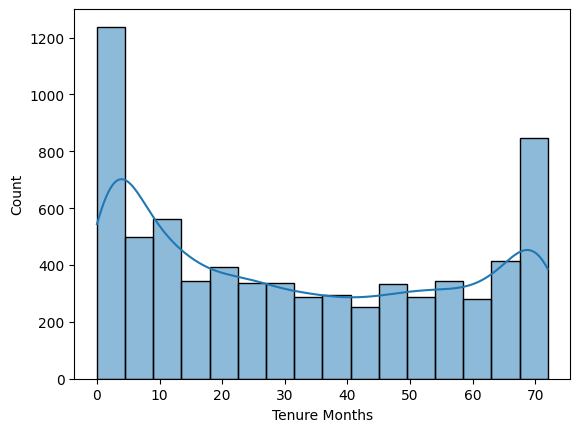

In [18]:
sns.histplot(data = df , x = 'Tenure Months'  , kde = True )
plt.show()

Most of customer churns in Initial months. To avoid churning they want to focus on giving satisfactory service to the new customers

<Axes: xlabel='Payment Method', ylabel='Total Charges'>

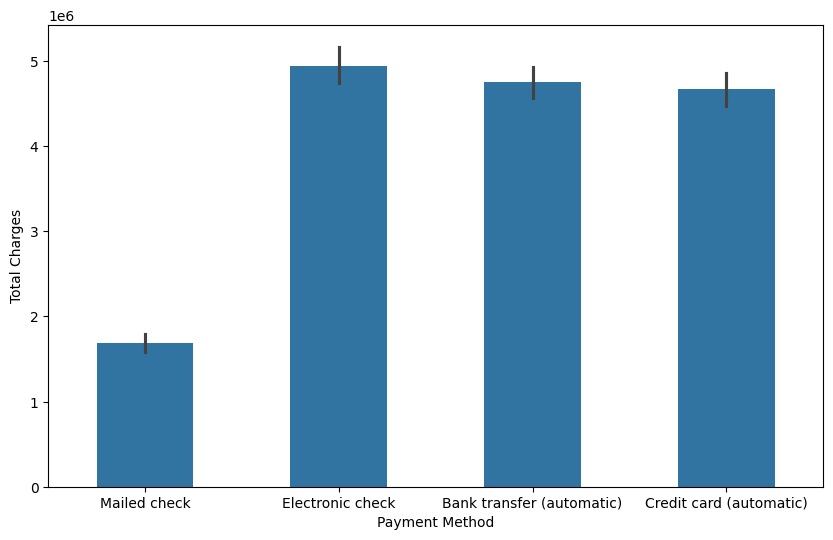

In [19]:
plt.figure(figsize = (10,6))
sns.barplot(
    x='Payment Method',
    y='Total Charges',
    data=df,
    estimator=sum,
    width=0.5  
)

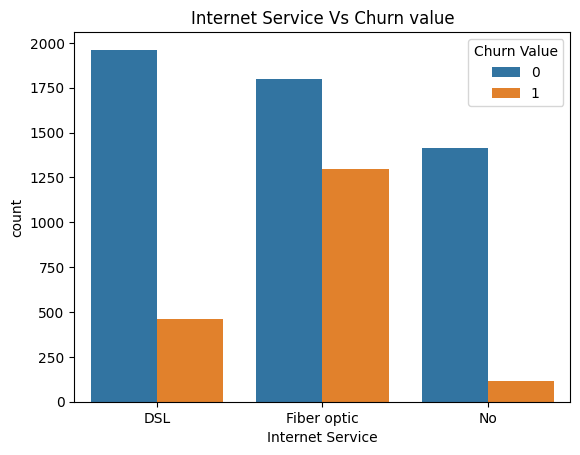

In [20]:
sns.countplot(x = 'Internet Service'  , hue = 'Churn Value' , data = df)
plt.title("Internet Service Vs Churn value")
plt.show()

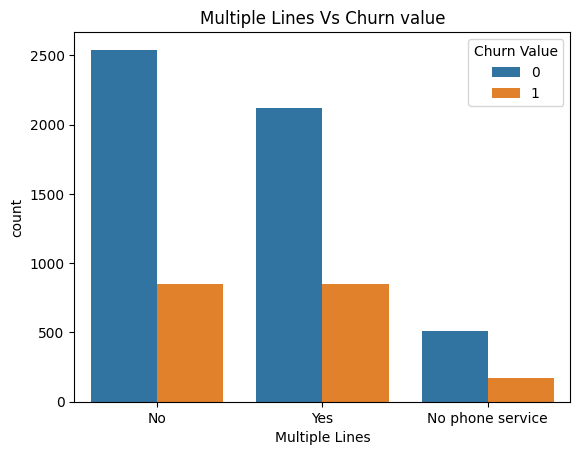

In [21]:
sns.countplot(x = 'Multiple Lines'  , hue = 'Churn Value' , data = df)
plt.title("Multiple Lines Vs Churn value")
plt.show()

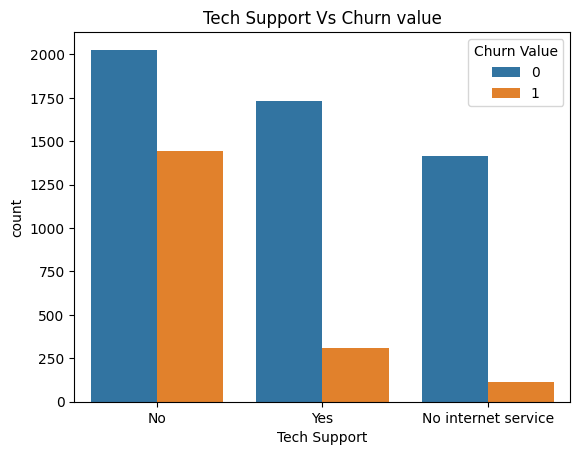

In [22]:
sns.countplot(x = 'Tech Support'  , hue = 'Churn Value' , data = df)
plt.title("Tech Support Vs Churn value")
plt.show()

## Machine Learning

In [23]:
remove_cols = ['CustomerID','Churn Label','Churn Score','Count','Country','State','Churn Reason','Lat Long','City','Zip Code','Latitude','Longitude','Gender']
df.drop(columns = remove_cols , inplace = True , errors = 'ignore')

In [24]:
df.columns

Index(['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'CLTV'],
      dtype='object')

In [25]:
numeric = df.select_dtypes(['int' , 'float']).columns
catagory = df.select_dtypes(['object']).columns

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [27]:
le = LabelEncoder()
for i in catagory:
    df[i] = le.fit_transform(df[i])

In [28]:
df.dtypes

Senior Citizen         int64
Partner                int64
Dependents             int64
Tenure Months          int64
Phone Service          int64
Multiple Lines         int64
Internet Service       int64
Online Security        int64
Online Backup          int64
Device Protection      int64
Tech Support           int64
Streaming TV           int64
Streaming Movies       int64
Contract               int64
Paperless Billing      int64
Payment Method         int64
Monthly Charges      float64
Total Charges        float64
Churn Value            int64
CLTV                   int64
dtype: object

In [29]:
X = df.drop(columns = 'Churn Value')
y = df['Churn Value']

In [30]:
scalar = StandardScaler()
X = scalar.fit_transform(X)
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
#Logistic Regression
model_lr = LogisticRegression(max_iter=200)
model_lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [32]:
#KNN
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
#Random Forest
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
#Model Prediction
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_knn = model_knn.predict(X_test)

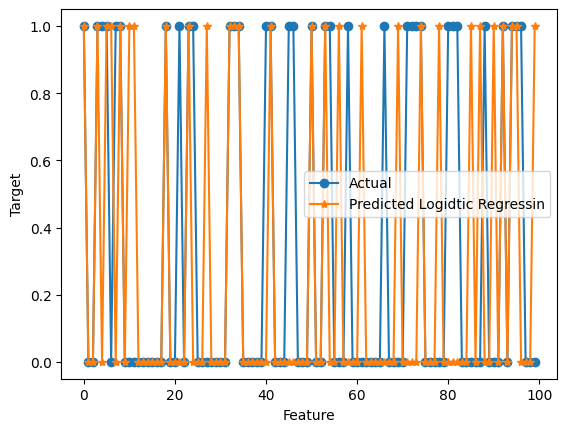

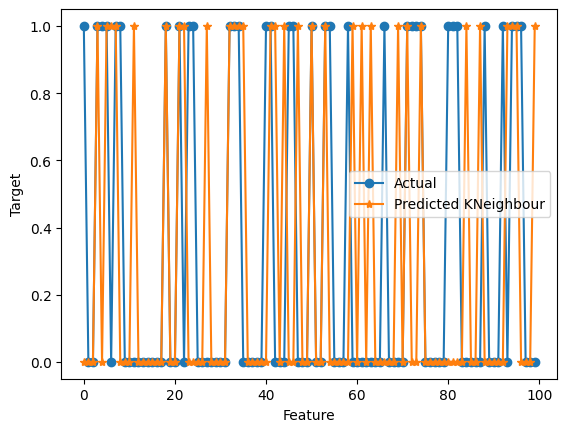

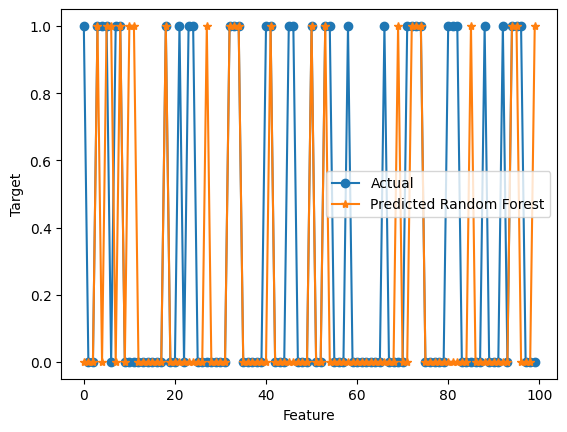

In [35]:
#Evaluation of model by visualization
plt.plot(y_test.values[:100] , label = "Actual" , marker = 'o')
plt.plot(y_pred_lr[:100] , label = "Predicted Logidtic Regressin" , marker = '*')
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()
plt.plot(y_test.values[:100] , label = "Actual" , marker = 'o')
plt.plot(y_pred_knn[:100] , label = "Predicted KNeighbour" , marker = '*')
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()
plt.plot(y_test.values[:100] , label = "Actual" , marker = 'o')
plt.plot(y_pred_rf[:100] , label = "Predicted Random Forest" , marker = '*')
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

In [36]:
cr_lr = classification_report(y_test , y_pred_lr)
cr_knn = classification_report(y_test , y_pred_knn)
cr_rf = classification_report(y_test , y_pred_rf)
print("Classifaction report of Logistic Regression:\n",cr_lr)
print("Classifaction report of KNeighbour:\n",cr_knn)
print("Classifaction report of Random Forest:\n",cr_rf)

Classifaction report of Logistic Regression:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      1009
           1       0.68      0.57      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Classifaction report of KNeighbour:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84      1009
           1       0.60      0.54      0.57       400

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.76      0.77      0.76      1409

Classifaction report of Random Forest:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.67      0.51      0.58       400

    accuracy                           0.79      1409
   ma

In [37]:
acc_lr = accuracy_score(y_test , y_pred_lr)
acc_knn = accuracy_score(y_test , y_pred_knn)
acc_rf = accuracy_score(y_test , y_pred_rf)
print("Accuracy Score of Logistic Regression:",acc_lr)
print("Accuracy Score of KNeighbour:",acc_knn)
print("Accuracy Score of Random Forest:",acc_rf) 

Accuracy Score of Logistic Regression: 0.8026969481902059
Accuracy Score of KNeighbour: 0.7665010645848119
Accuracy Score of Random Forest: 0.7906316536550745


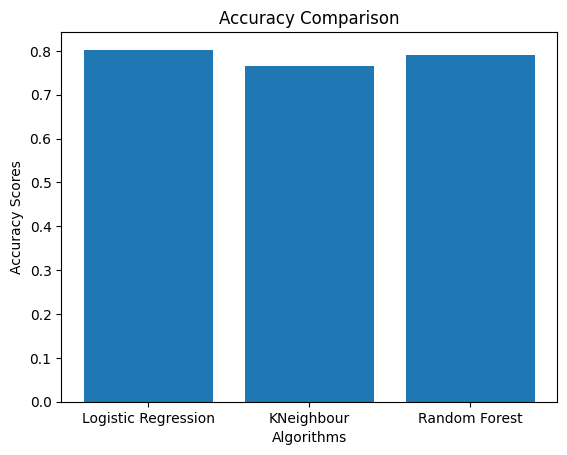

In [38]:
accuracy_list = [acc_lr , acc_knn , acc_rf]
algorithm_list = ["Logistic Regression" , "KNeighbour" , "Random Forest"]
plt.bar(algorithm_list , accuracy_list , label = "Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy Scores")
plt.title("Accuracy Comparison")
plt.show()